# CART + SMOTE — Árbol de decisión con Cost-Complexity Pruning

## I. Librerías

In [1]:
# ============================================================
# Librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# Modelado
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
from sklearn.inspection import permutation_importance

# Oversampling
from imblearn.over_sampling import SMOTE

## II. Carga y limpieza de datos

In [2]:
import os
DATASETS = glob.glob(os.path.join("dataset", "*.csv"))
print(DATASETS) 


dfs = [pd.read_csv(path) for path in DATASETS]
df = pd.concat(dfs, ignore_index=True)

['dataset\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'dataset\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'dataset\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'dataset\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'dataset\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'dataset\\Tuesday-WorkingHours.pcap_ISCX.csv']


### CLEAN DATA

In [3]:

# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# Separar features y target
X = df.drop("Label", axis=1)
y = df["Label"]

# Reemplazar infinitos y eliminar NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y[X.index]

print(f"Dataset: {X.shape[0]:,} filas × {X.shape[1]} columnas")
print("Clases:\n", y.value_counts())

Dataset: 1,606,989 filas × 78 columnas
Clases:
 Label
BENIGN                        1302156
PortScan                       158804
DDoS                           128025
FTP-Patator                      7935
SSH-Patator                      5897
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Name: count, dtype: int64


## III. División train / test

La partición se realiza antes de aplicar SMOTE 

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=1234,
    shuffle=True,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Train: 1,285,591 | Test: 321,398


## IV. Balanceo de clases con SMOTE

SMOTE genera muestras sintéticas para las clases minoritarias hasta alcanzar el umbral . Se aplica únicamente sobre el conjunto de train

In [5]:
y_train_1d = np.ravel(y_train)
counts = Counter(y_train_1d)

print("Distribución ANTES de SMOTE:")
print(counts)

# Submuestrear hasta cap solo las clases que estén por debajo
cap = 10_000
sampling_dict = {cls: cap for cls, c in counts.items() if c < cap}
print("Sampling strategy:", sampling_dict)

# k_neighbors seguro (no puede superar min_class - 1)
min_class = min(counts.values())
k = min(3, max(1, min_class - 1))
print(f"k_neighbors = {k}")

sm = SMOTE(sampling_strategy=sampling_dict, random_state=2, k_neighbors=k)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train_1d)

print("Distribución DESPUÉS de SMOTE:")
print(Counter(y_train_res))
print(f"Shape train tras SMOTE: {X_train_res.shape}")

Distribución ANTES de SMOTE:
Counter({'BENIGN': 1041725, 'PortScan': 127043, 'DDoS': 102420, 'FTP-Patator': 6348, 'SSH-Patator': 4717, 'Bot': 1565, 'Web Attack � Brute Force': 1205, 'Web Attack � XSS': 522, 'Infiltration': 29, 'Web Attack � Sql Injection': 17})
Sampling strategy: {'FTP-Patator': 10000, 'SSH-Patator': 10000, 'Web Attack � Brute Force': 10000, 'Bot': 10000, 'Web Attack � XSS': 10000, 'Web Attack � Sql Injection': 10000, 'Infiltration': 10000}
k_neighbors = 3
Distribución DESPUÉS de SMOTE:
Counter({'BENIGN': 1041725, 'PortScan': 127043, 'DDoS': 102420, 'FTP-Patator': 10000, 'SSH-Patator': 10000, 'Web Attack � Brute Force': 10000, 'Bot': 10000, 'Web Attack � XSS': 10000, 'Web Attack � Sql Injection': 10000, 'Infiltration': 10000})
Shape train tras SMOTE: (1341188, 78)


## V. Reducción de muestras para búsqueda de hiperparámetros


In [6]:
# Muestra estratificada de 10 000 filas : se usa SOLO para buscar el mejor alpha
X_train_s, _, y_train_s, _ = train_test_split(
    X_train_res, y_train_res,
    train_size=10_000,
    stratify=y_train_res,
    random_state=42
)

print(f"Muestra reducida: {X_train_s.shape}")
print(pd.Series(y_train_s).value_counts())

Muestra reducida: (10000, 78)
BENIGN                        7767
PortScan                       947
DDoS                           764
FTP-Patator                     75
Bot                             75
Infiltration                    75
Web Attack � Sql Injection      75
SSH-Patator                     74
Web Attack � Brute Force        74
Web Attack � XSS                74
Name: count, dtype: int64


## VI. Cost-Complexity Pruning (CCP)


Buscamoss el parámetro de penalización: --> *Error total = Error en training + α × número de hojas**


### Estrategia en dos pasos

Paso 1 : Exploración: calcular el rango real de alphas a partir de una muestra de 100 k filas


Paso 2 : GridSearchCV fino: evaluar 20 alphas en escala logarítmica con CV y métrica F1-macro 

### Si  devuelve α = 0

Cuando el mejor alpha es 0, el árbol queda sin poda. Esto puede ocurrir si:
- Los datos son suficientemente limpios y el árbol profundo no sobreajusta en CV.
- Las separaciones de clase son muy marcadas

En ese caso, se evalúa si la profundidad y el número de hojas son razonables. Si el árbol resulta excesivamente grande, se fuerza un alpha mínimo porque sino puede provocar overfitting.

In [7]:
# ============================================================
# PASO 1: Calcular rango de alphas sobre muestra grande (100k)
# ============================================================
X_path, _, y_path, _ = train_test_split(
    X_train_res, y_train_res,
    train_size=100_000,
    stratify=y_train_res,
    random_state=99
)

fulltree_path = DecisionTreeClassifier(random_state=2)
fulltree_path.fit(X_path, y_path)

path = fulltree_path.cost_complexity_pruning_path(X_path, y_path)
raw_alphas = path.ccp_alphas

# Descartar alpha=0 y valores extremadamente pequeños (< 1e-5)
raw_alphas = raw_alphas[raw_alphas > 1e-5]

# 20 alphas en escala logarítmica 
alphas_grid = np.geomspace(raw_alphas.min(), raw_alphas.max(), num=20)

print(f"Rango de alphas explorado: {alphas_grid.min():.2e}  →  {alphas_grid.max():.2e}")
print(f"Alphas a evaluar ({len(alphas_grid)}):")
print(np.round(alphas_grid, 6))

Rango de alphas explorado: 1.01e-05  →  7.49e-02
Alphas a evaluar (20):
[1.0000e-05 1.6000e-05 2.6000e-05 4.1000e-05 6.6000e-05 1.0500e-04
 1.6900e-04 2.6900e-04 4.3100e-04 6.8800e-04 1.1000e-03 1.7580e-03
 2.8100e-03 4.4920e-03 7.1800e-03 1.1477e-02 1.8345e-02 2.9323e-02
 4.6869e-02 7.4916e-02]


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejor alpha (GridSearchCV): 0.000169
F1-macro CV con ese alpha:  0.8676
Top 10 alphas por F1-macro:
   alpha  mean_f1   std_f1
0.000169 0.867602 0.020753
0.000269 0.866213 0.024187
0.000105 0.864365 0.021684
0.000010 0.864187 0.021820
0.000041 0.864187 0.021820
0.000026 0.864187 0.021820
0.000016 0.864187 0.021820
0.000066 0.864187 0.021820
0.000431 0.864116 0.022982
0.000688 0.840318 0.038580


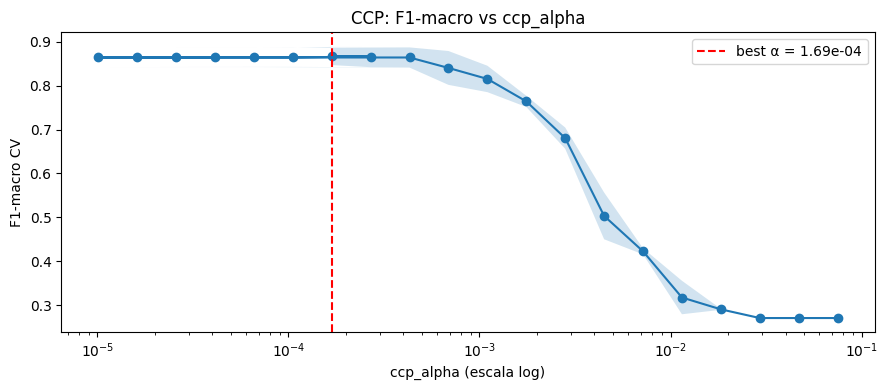

In [8]:
# ============================================================
# PASO 2: GridSearchCV sobre la muestra pequeña 
# CV=3, scoring=f1_macro 
# ============================================================
param_grid = {'ccp_alpha': alphas_grid}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring='f1_macro',
    verbose=1
)
grid.fit(X_train_s, y_train_s)

best_alpha = grid.best_params_['ccp_alpha']
print(f"Mejor alpha (GridSearchCV): {best_alpha:.6f}")
print(f"F1-macro CV con ese alpha:  {grid.best_score_:.4f}")

# Tabla completa de resultados
results_df = pd.DataFrame({
    'alpha':    alphas_grid,
    'mean_f1':  grid.cv_results_['mean_test_score'],
    'std_f1':   grid.cv_results_['std_test_score']
}).sort_values('mean_f1', ascending=False)

print("Top 10 alphas por F1-macro:")
print(results_df.head(10).to_string(index=False))

# Gráfico alpha vs F1
plt.figure(figsize=(9, 4))
plt.semilogx(results_df['alpha'], results_df['mean_f1'], marker='o')
plt.fill_between(results_df['alpha'],
                 results_df['mean_f1'] - results_df['std_f1'],
                 results_df['mean_f1'] + results_df['std_f1'],
                 alpha=0.2)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'best α = {best_alpha:.2e}')
plt.xlabel("ccp_alpha (escala log)")
plt.ylabel("F1-macro CV")
plt.title("CCP: F1-macro vs ccp_alpha")
plt.legend()
plt.tight_layout()
plt.show()

## VII. Entrenamiento del modelo final

Con el  k seleccionado, se entrena el árbol sobre todos los datos SMOTE, no sobre la muestra reducida. Esto garantiza que el modelo final aproveche toda la información disponible.

In [9]:
model_final = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=0)
model_final.fit(X_train_res, y_train_res)

print(f"Árbol final entrenado sobre {X_train_res.shape[0]:,} muestras")
print(f"Profundidad:      {model_final.get_depth()}")
print(f"Número de hojas:  {model_final.get_n_leaves()}")

if model_final.get_depth() > 30 or model_final.get_n_leaves() > 1000:
    print("El árbol es muy complejo. Considera aumentar ccp_alpha para reducir")
    print("   la complejidad y mejorar la interpretabilidad.")
else:
    print("Complejidad del árbol razonable.")

Árbol final entrenado sobre 1,341,188 muestras
Profundidad:      16
Número de hojas:  66
Complejidad del árbol razonable.


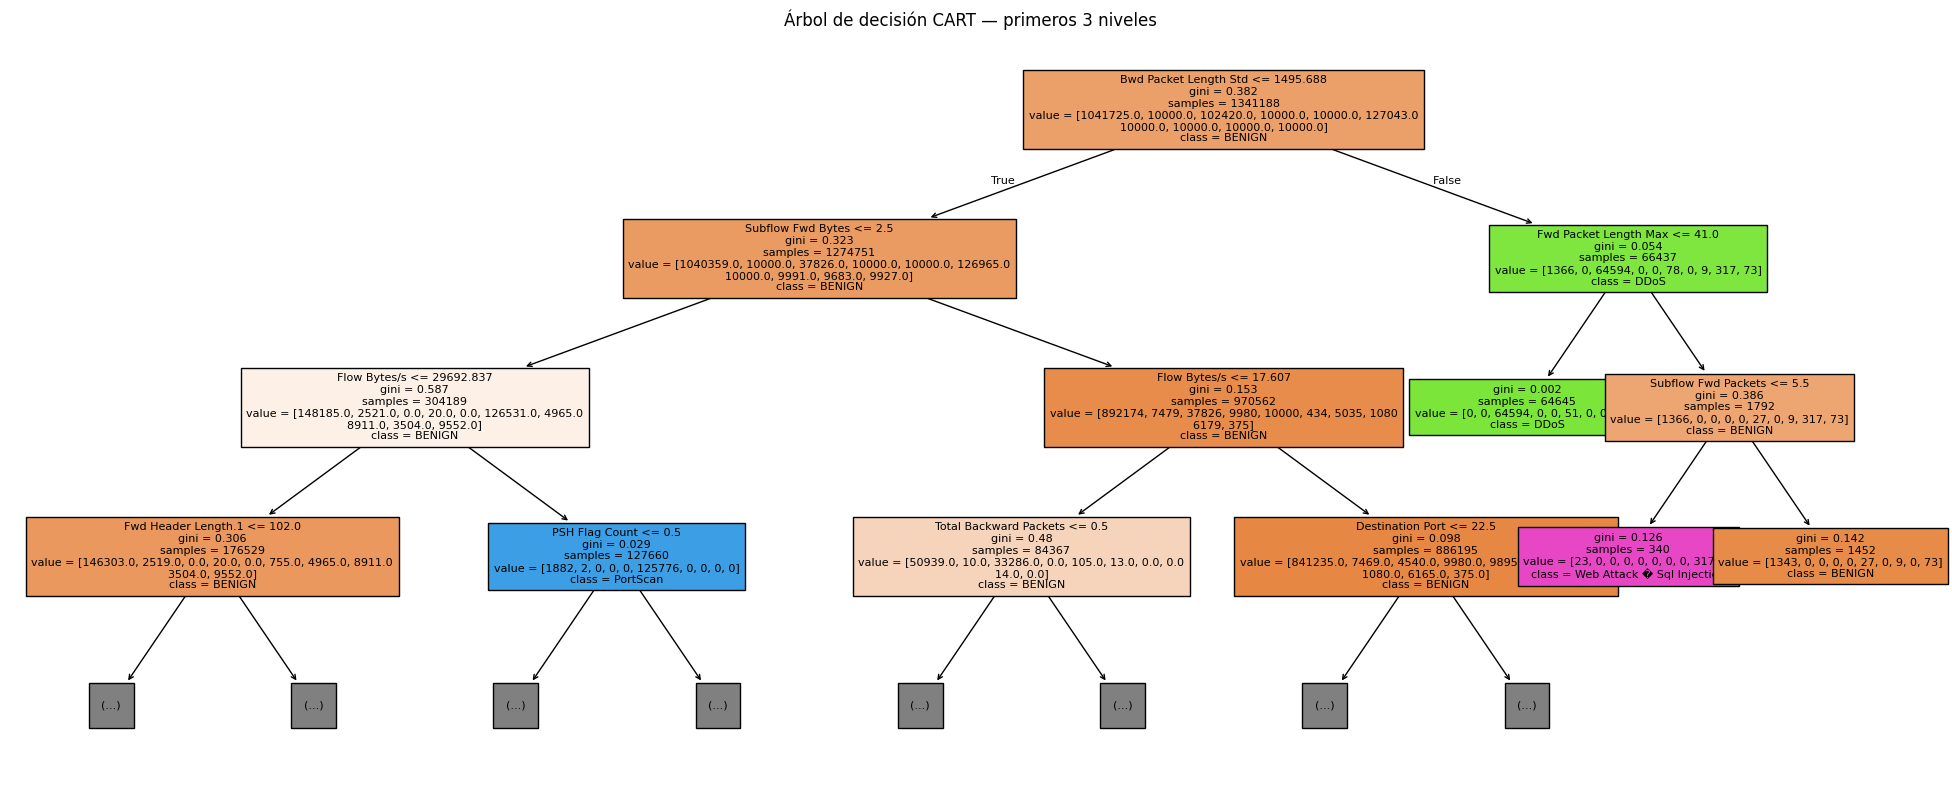

|--- Bwd Packet Length Std <= 1495.69
|   |--- Subflow Fwd Bytes <= 2.50
|   |   |--- Flow Bytes/s <= 29692.84
|   |   |   |--- Fwd Header Length.1 <= 102.00
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- Fwd Header Length.1 >  102.00
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- Flow Bytes/s >  29692.84
|   |   |   |--- PSH Flag Count <= 0.50
|   |   |   |   |--- class: BENIGN
|   |   |   |--- PSH Flag Count >  0.50
|   |   |   |   |--- class: PortScan
|   |--- Subflow Fwd Bytes >  2.50
|   |   |--- Flow Bytes/s <= 17.61
|   |   |   |--- Total Backward Packets <= 0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Total Backward Packets >  0.50
|   |   |   |   |--- class: BENIGN
|   |   |--- Flow Bytes/s >  17.61
|   |   |   |--- Destination Port <= 22.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Destination Port >  22.50
|   |   |   |   |--- truncated branch of depth 13
|--- Bwd Packet Length Std >  1495.69

In [10]:
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(20, 8))
plot_tree(model_final,
          max_depth=3,
          feature_names=X_train_res.columns.tolist(),
          class_names=sorted(np.unique(y_train_res)),
          filled=True,
          fontsize=8)
plt.title("Árbol de decisión CART — primeros 3 niveles")
plt.tight_layout()
plt.show()

print(export_text(model_final,
                  feature_names=X_train_res.columns.tolist(),
                  max_depth=3))

## VIII. Evaluación del modelo final

### 8.1 Evaluación en train

Evaluamos primero en train para detectar sobreajuste. Si la accuracy de train es mucho mayor que la de test, hay overfitting.

Accuracy train: 99.07 %

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00   1041725
                       Bot       0.91      0.90      0.90     10000
                      DDoS       1.00      1.00      1.00    102420
               FTP-Patator       1.00      1.00      1.00     10000
              Infiltration       0.99      0.92      0.95     10000
                  PortScan       0.99      1.00      0.99    127043
               SSH-Patator       1.00      0.99      1.00     10000
  Web Attack � Brute Force       0.75      0.51      0.61     10000
Web Attack � Sql Injection       0.98      0.93      0.96     10000
          Web Attack � XSS       0.62      0.78      0.69     10000

                  accuracy                           0.99   1341188
                 macro avg       0.92      0.90      0.91   1341188
              weighted avg       0.99      0.99      0.99   1341188



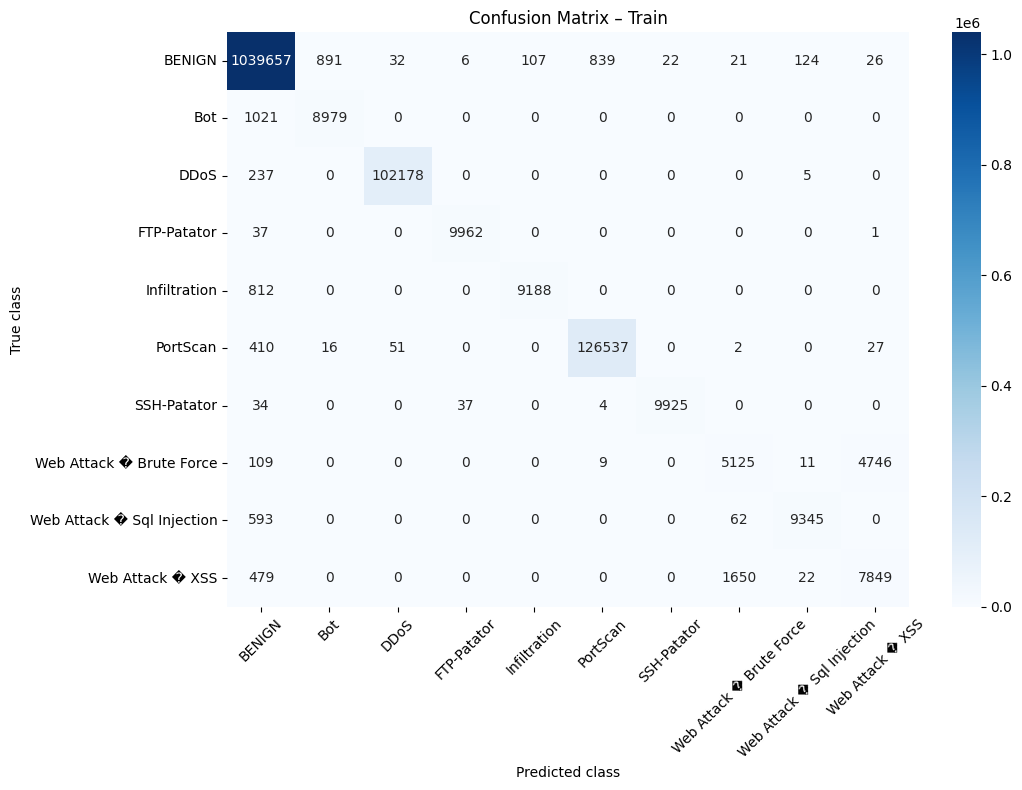

In [11]:
predictions_train = model_final.predict(X_train_res)

print("Accuracy train: {:.2f} %".format(100 * accuracy_score(y_train_res, predictions_train)))
print()
print(classification_report(y_train_res, predictions_train))

labels = sorted(np.unique(y_train_res))
cm_train = confusion_matrix(y_train_res, predictions_train, labels=labels)

plt.figure(figsize=(11, 8))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix – Train")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8.2 Evaluación en test

El conjunto de test no ha intervenido en ninguna fase de entrenamiento ni selección de hiperparámetros, por lo que representa el rendimiento real esperado.

Accuracy test: 99.70 %

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    260431
                       Bot       0.59      0.88      0.70       391
                      DDoS       1.00      1.00      1.00     25605
               FTP-Patator       1.00      1.00      1.00      1587
              Infiltration       0.12      0.57      0.21         7
                  PortScan       0.99      1.00      1.00     31761
               SSH-Patator       0.99      0.99      0.99      1180
  Web Attack � Brute Force       0.83      0.45      0.58       302
Web Attack � Sql Injection       0.08      0.75      0.14         4
          Web Attack � XSS       0.38      0.83      0.52       130

                  accuracy                           1.00    321398
                 macro avg       0.70      0.85      0.71    321398
              weighted avg       1.00      1.00      1.00    321398



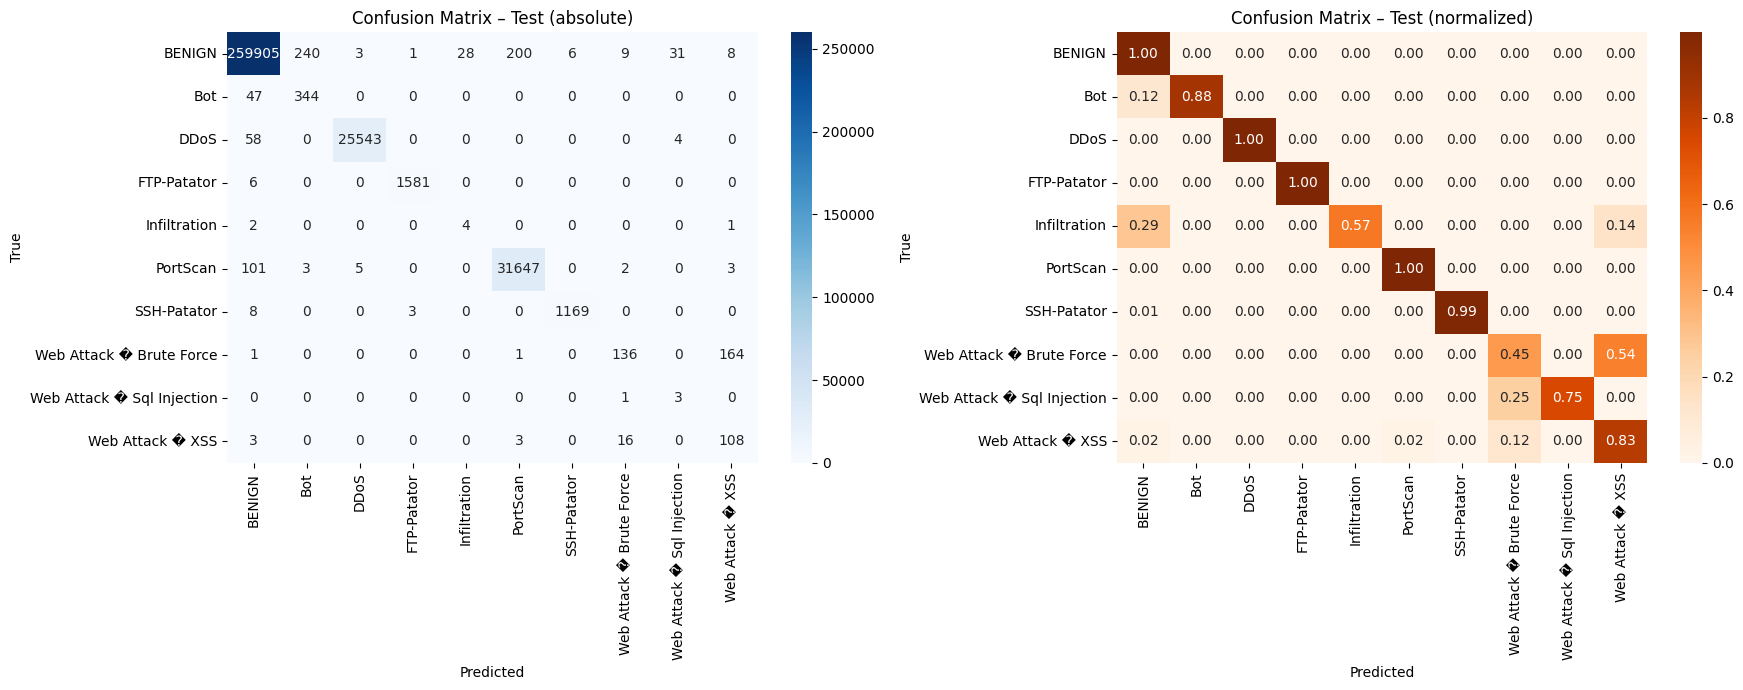

In [12]:
pred_test = model_final.predict(X_test)

print("Accuracy test: {:.2f} %".format(100 * accuracy_score(y_test, pred_test)))
print()
print(classification_report(y_test, pred_test))

labels_test = sorted(np.unique(y_test))
cm_test = confusion_matrix(y_test, pred_test, labels=labels_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_test, yticklabels=labels_test, ax=axes[0])
axes[0].set_title("Confusion Matrix – Test (absolute)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

cm_norm = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=labels_test, yticklabels=labels_test, ax=axes[1])
axes[1].set_title("Confusion Matrix – Test (normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

## IX. Importancia de variables (Permutation Importance)

La importancia de Gini nativa del árbol puede sobreestimar variables con alta cardinalidad.  es más robusta: mide cuánto cae el F1-macro al permutar aleatoriamente cada variable en el conjunto de test.

- **Valor alto** :  la variable es crítica para el modelo.  
- **Valor negativo** : la variable puede añadir ruido 

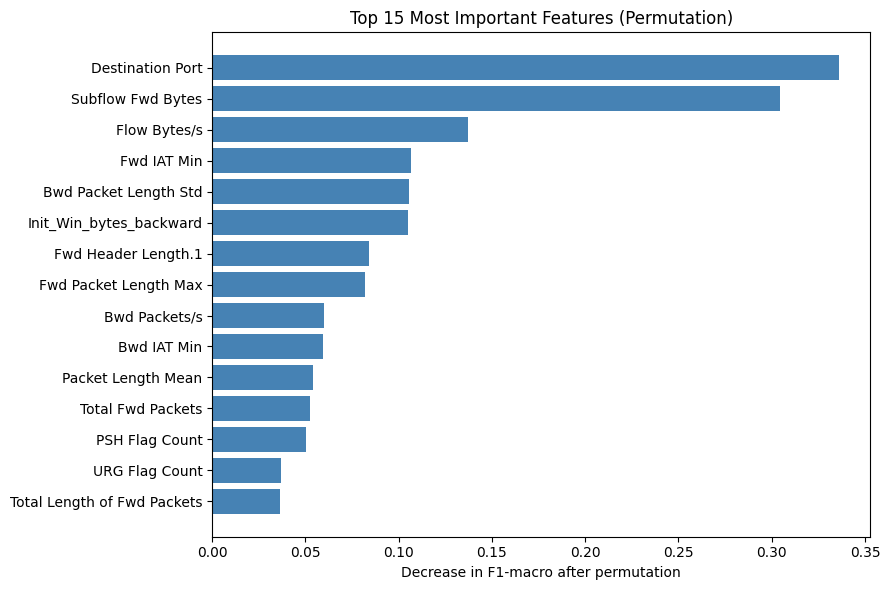

Top 20 variables por importancia:
                    Feature  Importance
           Destination Port    0.335944
          Subflow Fwd Bytes    0.304174
               Flow Bytes/s    0.137189
                Fwd IAT Min    0.106469
      Bwd Packet Length Std    0.105638
    Init_Win_bytes_backward    0.105029
        Fwd Header Length.1    0.084255
      Fwd Packet Length Max    0.081943
              Bwd Packets/s    0.059825
                Bwd IAT Min    0.059442
         Packet Length Mean    0.053918
          Total Fwd Packets    0.052394
             PSH Flag Count    0.050411
             URG Flag Count    0.036651
Total Length of Fwd Packets    0.036198
     Init_Win_bytes_forward    0.027062
     Fwd Packet Length Mean    0.025681
        Average Packet Size    0.021971
                Active Mean    0.019514
       Avg Bwd Segment Size    0.019307


In [13]:
result = permutation_importance(
    model_final, X_test, y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)

imp_df = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False)

top_n = 15
imp_top = imp_df.head(top_n).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(imp_top['Feature'], imp_top['Importance'], color='steelblue')
plt.xlabel("Decrease in F1-macro after permutation")
plt.title(f"Top {top_n} Most Important Features (Permutation)")
plt.tight_layout()
plt.show()

print("Top 20 variables por importancia:")
print(imp_df.head(20).to_string(index=False))